Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load the Old Faithful Dataset

In [2]:
url = "https://people.sc.fsu.edu/~jburkardt/data/csv/faithful.csv"

data = pd.read_csv(url)

data = data.iloc[:,1:]

X = data.values
print(data.head())

    "Eruption length (mins)"  Eruption wait (mins)
0                      3.600                    79
1                      1.800                    54
2                      3.333                    74
3                      2.283                    62
4                      4.533                    85


Define Euclidean Distance

In [3]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))

Implement K-Means from Scratch

In [4]:
def kmeans(X, K=2, max_iter=100, tol=1e-4):

  n_samples, n_features = X.shape

  centroids = X[np.random.choice(n_samples, K, replace=False)]
  objective_values = []

  for iteration in range(max_iter):
    clusters = [[] for _ in range(K)]

    for idx, point in enumerate(X):
      distances = [euclidean_distance(point, centroid) for centroid in centroids]
      cluster_index = np.argmin(distances)
      clusters[cluster_index].append(idx)

    new_centroids = np.zeros_like(centroids)

    for i in range(K):
      new_centroids[i] = np.mean(X[clusters[i]], axis=0)

    J=0
    for i in range(K):
      for idx in clusters[i]:
        J+= np.sum((X[idx] - new_centroids[i])**2)

    objective_values.append(J)

    centroid_shift = np.linalg.norm(new_centroids - centroids)
    if centroid_shift < tol:
      print(f"Converged at iteration {iteration}")
      break

    centroids = new_centroids

  return clusters, centroids, objective_values

Run K-Means

In [5]:
clusters, centroids, objective_values = kmeans(X, K=2, max_iter=100, tol=1e-4)

print("Final Centroids:")
print(centroids)

Converged at iteration 5
Final Centroids:
[[ 4.29793023 80.28488372]
 [ 2.09433    54.75      ]]


Plot Clustered Dataset

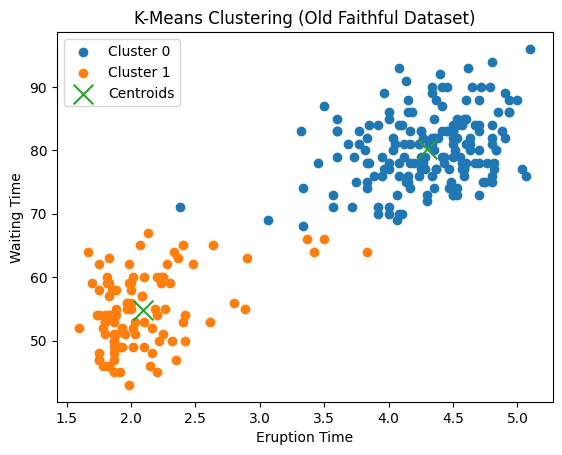

In [6]:
plt.figure()

for i, cluster in enumerate(clusters):
    points = X[cluster]
    plt.scatter(points[:,0], points[:,1], label=f'Cluster {i}')

plt.scatter(centroids[:,0], centroids[:,1], marker='x', s=200, label='Centroids')

plt.xlabel("Eruption Time")
plt.ylabel("Waiting Time")
plt.title("K-Means Clustering (Old Faithful Dataset)")
plt.legend()

plt.show()

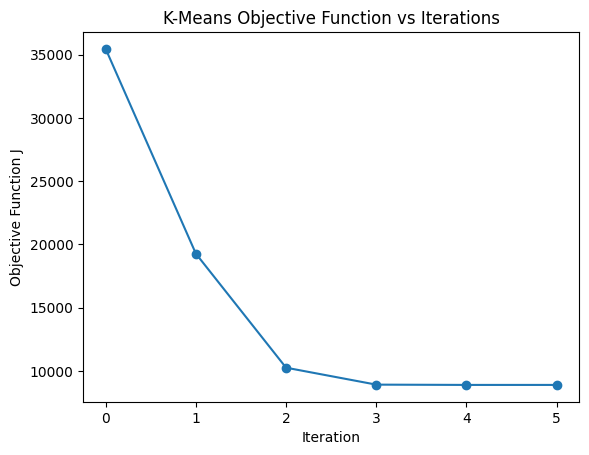

In [8]:
plt.figure()

plt.plot(objective_values, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Objective Function J")
plt.title("K-Means Objective Function vs Iterations")

plt.show()